<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [140]:
#Importation de la librairie Pandas
import pandas as pd

In [141]:
#Importation de la librairie plotly express
import plotly.express as px

In [142]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [143]:
#Importation du fichier web.xlsx
df_web = pd.read_excel(".\\Data+Bottleneck\\web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel(".\\Data+Bottleneck\\erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel(".\\Data+Bottleneck\\liaison.xlsx")

C:\Users\Admin\Documents\GRETA\P4\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\Admin\Documents\GRETA\P4\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\Admin\Documents\GRETA\P4\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [144]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {df_erp.shape[0]} observation(s) ou article(s)")
print(f"Le tableau comporte {df_erp.shape[1]} colonne(s)")

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [145]:
#Consulter le nombre de colonnes
print(f"{df_erp.shape[1]} colonnes")
#La nature des données dans chacune des colonnes
df_erp.info()
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.count()

6 colonnes
<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB


product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64

In [146]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [147]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp.duplicated(subset='product_id').sum()

np.int64(0)

In [148]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp.stock_status.unique()

#À quelle(s) autre(s) colonne(s) sont-elles liées ?

<StringArray>
['instock', 'outofstock']
Length: 2, dtype: str

La colonne stock_status donne l'indication de si le produit est en stock ou non. L'information est liée à la colonne stock_quantity.

Au lieu vérifier directement si on est bien en outofstock quand le stock_quantity est 0, on crée une colonne de test, que l'on comparera avec la colonne stock_status existante.

In [149]:
#Création d'une colonne "stock_status_2"
df_erp['stock_status_2'] = ""

#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(
    lambda x: 'outofstock' if x == 0 else 'instock'
)


In [150]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [151]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
### Somme de 825, énoncé incorrect
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(821)

In [152]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[df_erp['stock_status'] != df_erp['stock_status_2']]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [153]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp['stock_quantity'] < 0, 'stock_quantity'] = 0
df_erp['stock_status'] = df_erp['stock_quantity'].apply(
    lambda x: 'outofstock' if x == 0 else 'instock'
)
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
### Recréation de la colonne de test suite à la modification des stocks négatifs
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(
    lambda x: 'outofstock' if x == 0 else 'instock'
)
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(825)

On trouve bien 825, supression de la colonne de test

In [154]:
df_erp.drop("stock_status_2", axis=1, inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [155]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isna().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print(f"Prix minimum : {df_erp['price'].min()}")
#Afficher le prix maximum de la colonne "price"
print(f"Prix maximum : {df_erp['price'].max()}")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
df_erp[df_erp['price'] < 0]

Nombres d'articles avec un prix non renseigné: 0
Prix minimum : -20.0
Prix maximum : 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.0,0,outofstock,10.33
469,5017,0,-8.0,0,outofstock,4.34
739,6594,0,-9.1,19,instock,4.61


Une correction va être apporter, mais une validation de saisie dans l'ERP serait une solution à long-terme

In [156]:
df_erp['price'] = df_erp['price'].abs()
df_erp[df_erp['price'] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [157]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(f"Quantité minimum : {df_erp['stock_quantity'].min()}")
#Afficher la quantité maximum de la colonne "stock_quantity"
print(f"Quantité maximum : {df_erp['stock_quantity'].max()}")
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
display(df_erp.loc[df_erp['stock_quantity'] < 0])

Quantité minimum : 0
Quantité maximum : 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


On rappelle que les produits 4973 et 5700 avaient des stock_quantity négatives avant nettoyage. On note ces deux références pour demander une investigation métier, et/ou pour d'autres analyses plus poussées ici.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [158]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].value_counts()

onsale_web
1    716
0    109
Name: count, dtype: int64

On a 716 produits vendus sur le site, contre 109 non vendu sur le site.
Le nom de la colonne est aussi interprétable comme "en solde sur le site" mais cela fait moins de sens d'un point de vue métier.

In [159]:
#Quelles sont les colonnes à conserver selon vous?

Toutes, même si on pourrait arguer que stock_status n'est qu'une analyse de stock_quantity et est donc redondante.

In [160]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".

Suppression déjà effectuée

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [161]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(f"Prix d'achat non renseignés: {df_erp['purchase_price'].isna().sum()}")
#Afficher le prix minimum de la colonne "purchase_price"
print(f"purchase_price minimum : {df_erp['purchase_price'].min()}")
#Afficher le prix maximum de la colonne "purchase_price"
print(f"purchase_price maximum : {df_erp['purchase_price'].max()}")

Prix d'achat non renseignés: 0
purchase_price minimum : 2.74
purchase_price maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [162]:
#Dimension du dataset
#Nombre d'observations
print(f"{df_web.shape[0]} observations")
#Nombre de caractéristiques
print(f"{df_web.shape[1]} caractéristiques")

1513 observations
29 caractéristiques


Dimensions supérieures aux données de l'ERP.

In [163]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   str           
 13  post_title    

On supprime les colonnes vides: tax_class, post_content, post_password et post_content_filtered

In [164]:
df_web.drop(["tax_class", "post_content", "post_password", "post_content_filtered"], axis=1, inplace=True)

On regarde les valeurs contenues dans les colonnes restantes

In [165]:
for i in df_web.columns:
    nb = len(df_web[i].unique())
    # Condition posée après avoir executé la cellule une première fois, pour avoir une meilleure lisibilité
    if i != "sku" and i != "post_excerpt":
        print(f"{nb} valeur(s) unique(s) dans la colonne {i}")
        print(df_web[i].unique())

1 valeur(s) unique(s) dans la colonne virtual
[0]
1 valeur(s) unique(s) dans la colonne downloadable
[0]
1 valeur(s) unique(s) dans la colonne rating_count
[0]
2 valeur(s) unique(s) dans la colonne average_rating
[ 0. nan]
30 valeur(s) unique(s) dans la colonne total_sales
[  3.   5.  14.   2.   4.  10.  nan  17.  13.  15.  12.   6.   7.  11.
  16.   8.   0.   9.  24.  18. 111.  20.  27.   1.  22. 122. 116.  36.
 -56. -17.]
2 valeur(s) unique(s) dans la colonne tax_status
<StringArray>
[nan, 'taxable']
Length: 2, dtype: str
3 valeur(s) unique(s) dans la colonne post_author
[ 2. nan  1.]
717 valeur(s) unique(s) dans la colonne post_date
<DatetimeArray>
['2018-02-12 13:46:23', '2018-04-17 15:29:17', '2019-03-19 10:06:47',
 '2018-02-15 14:05:06', '2019-03-27 18:05:09', '2019-03-19 15:58:25',
 '2018-06-02 09:31:31', '2018-02-28 14:46:15',                 'NaT',
 '2019-03-19 11:33:39',
 ...
 '2018-04-17 21:08:33', '2018-02-12 14:34:12', '2018-02-12 15:36:40',
 '2018-02-28 16:37:33', '2018-0

In [166]:
#Selon vous, quelles sont les colonnes à conserver ?
cols_web_keep = ['sku', 'total_sales', 'product_type', 'post_title', 'post_type']
### post_type n'est gardé que le temps d'appliquer un filtre pour ne prendre en compte que les 'product'.

Les colonnes virtual, downloadable et rating_count contiennent toujours 0. D'autres colonnes ont soit une valeur unique, soit nan, donc même traitement, c'est le cas de average_rating, tax_status, post_status, comment_status, ping_status, post_parent, menu_order, post_mime_type et comment_count.
Les données de date de post et modification de post ne nous intéressent pas, comme on a déjà eu des informations de date par Nicolas : post_date, post_date_gmt, post_modified, post_modified_gmt.
Et enfin, post_author ne nous intéresse pas, post_name est une autre nomenclature de post_title, et guid est un indicateur technique.

In [167]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[cols_web_keep]

In [168]:
#Visualisation des valeurs de la colonne sku
df_web['sku'].value_counts() ### Suspicion de doublon
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
temp = df_web[~df_web['sku'].astype(str).str.match(r'^\d{2,6}$')]
temp[temp['sku'].notna()]

,sku,total_sales,product_type,post_title,post_type
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product
842,bon-cadeau-25-euros,7.0,Autre,Bon cadeau de 25€,attachment
1117,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€,product


In [169]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les

Le bon cadeau est un cas particulier, que l'on va ignorer ici. Quand au sku 13127-1, il pourrait être intéressant de voir si c'est une erreur de saisie et retrouver la version correcte via la table liaison, pas encore analysée.

In [170]:
#Identifier les lignes sans code article
df_web[df_web['sku'].isna()]

,sku,total_sales,product_type,post_title,post_type
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [171]:
df_web[df_web['sku'].isna()].dropna(how='all')

,sku,total_sales,product_type,post_title,post_type
1084,NaN,-56.0,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product
1087,NaN,-17.0,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product


In [172]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

Il pourrait être intéressant de voir si on peut retrouver la version correcte via la table liaison, pas encore analysée.

In [173]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
df_web.loc[df_web.duplicated()]

,sku,total_sales,product_type,post_title,post_type
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [174]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_no_id = df_web.loc[df_web['sku'].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_no_id.info()
#3 - Que constatez-vous?

<class 'pandas.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   product_type  2 non-null      str    
 3   post_title    2 non-null      str    
 4   post_type     2 non-null      str    
dtypes: float64(1), object(1), str(3)
memory usage: 4.0+ KB


In [175]:
df_web.dropna(how='all', inplace=True)

In [176]:
df_web[df_web['post_type'] == 'product']

,sku,total_sales,product_type,post_title,post_type
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,product
6,16515,10.0,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,product
11,16585,15.0,Vin,Xavier Frissant Touraine Sauvignon 2019,product
14,12869,7.0,Vin,Stéphane Tissot Arbois D.D. 2016,product
...,...,...,...,...,...
1503,13074,4.0,Vin,Château de Vaudieu Châteauneuf-du-Pape L'Avenu...,product
1505,16322,0.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,product
1507,12365,10.0,Vin,Parés Baltà Penedès Electio 2013,product
1508,16326,5.0,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,product


In [177]:
df_web = df_web[df_web['post_type'] == 'product']
df_web.drop('post_type', axis=1, inplace=True)

In [178]:
df_web.info()

<class 'pandas.DataFrame'>
Index: 716 entries, 2 to 1509
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   716 non-null    float64
 2   product_type  715 non-null    str    
 3   post_title    716 non-null    str    
dtypes: float64(1), object(1), str(2)
memory usage: 28.0+ KB


Le fichier liaison ne comportant pas assez d'information pour retrouver les produits sans SKU

In [179]:
df_web = df_web.dropna(subset=['sku'])

In [180]:
df_web.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  713 non-null    str    
 3   post_title    714 non-null    str    
dtypes: float64(1), object(1), str(2)
memory usage: 27.9+ KB


In [181]:
df_web[df_web['product_type'].isna()]

,sku,total_sales,product_type,post_title
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [182]:
#Dimension du dataset
#Nombre d'observations
print(f"{df_liaison.shape[0]} observations")
#Nombre de caractéristiques
print(f"{df_liaison.shape[1]} caractéristiques")

825 observations
2 caractéristiques


In [183]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [184]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison['product_id'].nunique()

825

In [185]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison['id_web'].nunique()

734

In [186]:
#Avons-nous des articles sans correspondance?
print(f"id_web manquants: {df_liaison['id_web'].isna().sum()}")

id_web manquants: 91


In [187]:
# id_web présents dans liaison mais absents du fichier web
not_in_web = df_liaison[
    (df_liaison['id_web'].notna()) &
    (~df_liaison['id_web'].isin(df_web['sku']))
]
print(f"id_web non trouvés dans le fichier web: {not_in_web.shape[0]}")
not_in_web

id_web non trouvés dans le fichier web: 20


,id_web,product_id
193,13771,4289
236,15065,4568
241,14785,4584
355,12601,4741
391,15154,4864
394,14360,4869
424,15608,4921
425,15586,4922
470,15272,5018
473,15630,5021


In [188]:
print(f"id_web orphelins (non trouvés dans web): {not_in_web.shape[0]}")

# SKU avec format atypique (contiennent un tiret)
print(f"\nSKU avec format atypique:")
df_liaison[df_liaison['id_web'].astype(str).str.contains('-', na=False)]

id_web orphelins (non trouvés dans web): 20

SKU avec format atypique:


,id_web,product_id
443,bon-cadeau-25-euros,4954
822,13127-1,7247
823,14680-1,7329


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [189]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='left')
df_merge.shape

(825, 7)

In [190]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
print(f"Lignes sans id_web: {df_merge['id_web'].isna().sum()}")

Lignes sans id_web: 91


On a 91 produits pas vendus en ligne

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [191]:
#Fusionner les datasets df_merge et df_web
df_merge = pd.merge(df_merge, df_web, left_on='id_web', right_on='sku', how='left')
df_merge.shape

(825, 11)

In [192]:
#Avons-nous des lignes sans correspondance?
print(f"Lignes totales: {df_merge.shape[0]}")
print(f"Lignes sans données web (total_sales NaN): {df_merge['total_sales'].isna().sum()}")

Lignes totales: 825
Lignes sans données web (total_sales NaN): 111


91 lignes sans id_web, mais 111 lignes total, pourquoi ?

In [193]:
no_web = df_merge[df_merge['total_sales'].isna()]
print(f"Sans id_web du tout: {no_web['id_web'].isna().sum()}")
print(f"Avec id_web mais sans match web: {no_web['id_web'].notna().sum()}")

Sans id_web du tout: 91
Avec id_web mais sans match web: 20


20 produits soit retirés du site, soit erreur de référencement

In [194]:
no_web[no_web['id_web'].notna()][['product_id', 'id_web', 'price', 'stock_quantity']]

,product_id,id_web,price,stock_quantity
193,4289,13771,22.8,0
236,4568,15065,21.5,0
241,4584,14785,32.3,0
355,4741,12601,12.4,0
391,4864,15154,8.3,0
394,4869,14360,17.2,0
424,4921,15608,13.8,0
425,4922,15586,21.5,0
470,5018,15272,15.4,0
473,5021,15630,17.1,0


On a un stock de 3 * 27.9 + 14 * 26.5 = 454.7€ qui n'est pas achetable en ligne. Il faut donc trouver une manière de l'écouler, soit remettre en ligne, soit différemment

In [195]:
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017


Redondance de sku et id_web

In [196]:
df_merge = df_merge.drop('sku', axis=1)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: title={'center': 'Répartition des prix'}>

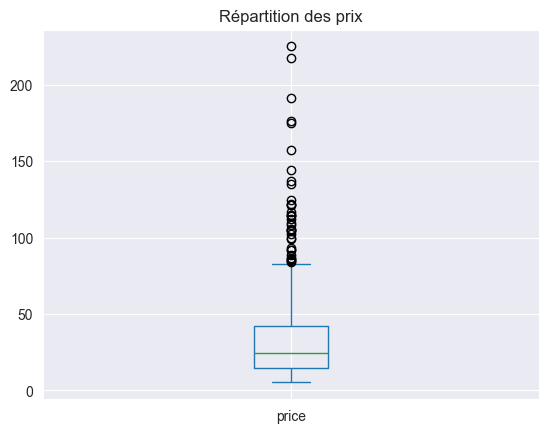

In [197]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge['price'].plot(kind='box', title='Répartition des prix')

In [198]:
#Autre méthode avec plotly express
fig = px.box(df_merge, y='price', title='Répartition des prix des articles')
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [199]:
#Calculer la moyenne du prix
mean_price = df_merge['price'].mean()
print(f"Moyenne: {mean_price:.2f}€")

#Calculer l'écart-type du prix
std_price = df_merge['price'].std()
print(f"Écart-type: {std_price:.2f}€")

#Calculer le Z-score
df_merge['z_score'] = (df_merge['price'] - mean_price) / std_price
print(f"Z-score: {df_merge['z_score']}")

Moyenne: 32.28€
Écart-type: 26.60€
Z-score: 0     -0.303634
1      0.076020
2     -0.431438
3     -0.683288
4      0.515816
         ...   
820    0.478227
821    0.478227
822    0.846604
823   -0.217178
824   -0.600591
Name: z_score, Length: 825, dtype: float64


In [200]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
outliers_z = df_merge[df_merge['z_score'].abs() > 3]
print(f"Nombre d'outliers (Z > 3): {outliers_z.shape[0]}")
print(f"Seuil de prix correspondant: {mean_price + 3 * std_price:.2f}€")
outliers_z[['product_id', 'price', 'post_title', 'product_type', 'z_score']]

Nombre d'outliers (Z > 3): 17
Seuil de prix correspondant: 112.09€


,product_id,price,post_title,product_type,z_score
208,4352,225.0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,7.244331
227,4402,176.0,Cognac Frapin VIP XO,Cognac,5.402447
230,4406,157.0,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac,4.688247
242,4594,144.0,NaN,NaN,4.199584
411,4904,137.0,Domaine Des Croix Corton Charlemagne Grand Cru...,Vin,3.936458
460,5001,217.5,David Duband Charmes-Chambertin Grand Cru 2014,Vin,6.962410
556,5612,124.8,Domaine Weinbach Gewurztraminer Grand Cru Furs...,Vin,3.477866
598,5767,175.0,Camille Giroud Clos de Vougeot 2016,Vin,5.364858
635,5892,191.3,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,5.977566
651,5917,122.0,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,Whisky,3.372616


In [201]:
df_merge = df_merge.drop('z_score', axis=1)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [202]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge['price'].describe()

count    825.000000
mean      32.277636
std       26.603196
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [203]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_merge['price'].quantile(0.25)
Q3 = df_merge['price'].quantile(0.75)
IQR = Q3 - Q1

seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Seuil bas: {seuil_bas}")
print(f"Seuil haut: {seuil_haut}")

Q1: 14.5
Q3: 42.0
IQR: 27.5
Seuil bas: -26.75
Seuil haut: 83.25


In [204]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_iqr = df_merge[df_merge['price'] > seuil_haut]

print(f"Nombre d'articles outliers: {outliers_iqr.shape[0]}")
print(f"Proportion du catalogue: {outliers_iqr.shape[0] / df_merge.shape[0] * 100:.1f}%")

Nombre d'articles outliers: 36
Proportion du catalogue: 4.4%


In [205]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
outliers_iqr[['price', 'post_title', 'product_type']].sort_values('price', ascending=False)

,price,post_title,product_type
208,225.0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne
460,217.5,David Duband Charmes-Chambertin Grand Cru 2014,Vin
635,191.3,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne
227,176.0,Cognac Frapin VIP XO,Cognac
598,175.0,Camille Giroud Clos de Vougeot 2016,Vin
230,157.0,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac
242,144.0,NaN,NaN
411,137.0,Domaine Des Croix Corton Charlemagne Grand Cru...,Vin
697,135.0,Champagne Gosset Célébris Vintage 2007,Champagne
556,124.8,Domaine Weinbach Gewurztraminer Grand Cru Furs...,Vin


In [206]:
outliers_iqr['product_type'].value_counts()

product_type
Vin          19
Champagne     6
Cognac        4
Whisky        3
Name: count, dtype: int64

In [208]:
fig = px.box(df_merge[df_merge['product_type'].notna()],
             x='product_type', y='price',
             title='Répartition des prix par type de produit')
fig.show()

Ces outliers sont justifiés. Les catégories Cognac et Champagne sont plus chères, la catégorie Vin est hétérogène (comprend des vins à 5€ comme des vins d'exception), et les 3 outliets Whisky sont des Whisky d'exceptions.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [663]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge['ca_par_article'] = df_merge['price'] * df_merge['total_sales']

#Calculer la somme de la colonne "ca_par_article"
ca_total = df_merge['ca_par_article'].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print(f"Chiffre d'affaires du site web: {ca_total:.2f}€")


Chiffre d'affaires du site web: 143680.10€


In [664]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_top_ca = df_merge.dropna(subset=['ca_par_article']).sort_values('ca_par_article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_top_ca.reset_index(drop=True, inplace=True)

#Afficher les 20 premiers articles en CA
df_top_ca.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_top_ca.head(20), x='ca_par_article', y='post_title',
             orientation='h',
             title='Top 20 des articles en CA')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [665]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_top_ca['part_ca'] = df_top_ca['ca_par_article'] / ca_total

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_top_ca['part_ca_cumul'] = df_top_ca['part_ca'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_80 = (df_top_ca['part_ca_cumul'] <= 0.80).sum() + 1

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
total_articles_ventes = df_top_ca[df_top_ca['ca_par_article'] > 0].shape[0]

print(f"Nombre d'articles représentant 80% du CA: {nb_80}")
print(f"Sur un total de {total_articles_ventes} articles vendus")
print(f"Proportion: {nb_80/total_articles_ventes*100:.1f}%")
df_merge = df_merge.drop('ca_par_article', axis=1)

Nombre d'articles représentant 80% du CA: 435
Sur un total de 689 articles vendus
Proportion: 63.1%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [666]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_top_qty = df_merge.dropna(subset=['total_sales']).sort_values('total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_top_qty.reset_index(drop=True, inplace=True)

#Afficher les 20 premiers articles en quantité
df_top_qty.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_top_qty.head(20), x='total_sales', y='post_title',
             orientation='h',
             title='Top 20 des articles en quantité vendue')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [667]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
total_qty = df_top_qty['total_sales'].sum()
df_top_qty['part_qty'] = df_top_qty['total_sales'] / total_qty

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_top_qty['part_qty_cumul'] = df_top_qty['part_qty'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_80_qty = (df_top_qty['part_qty_cumul'] <= 0.80).sum() + 1

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
total_articles_vendus = df_top_qty[df_top_qty['total_sales'] > 0].shape[0]
print(f"Quantité totale vendue: {total_qty:.0f} bouteilles")
print(f"Articles représentant 80% des ventes: {nb_80_qty}")
print(f"Proportion: {nb_80_qty/total_articles_vendus*100:.1f}%")


Quantité totale vendue: 5751 bouteilles
Articles représentant 80% des ventes: 434
Proportion: 63.0%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [668]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np

#Création de la colonne Rotation de stock
df_merge['rotation_stock'] = df_merge['stock_quantity'] / df_merge['total_sales']

#Remplacement des "inf" par 0
df_merge['rotation_stock'] = df_merge['rotation_stock'].replace([np.inf, -np.inf], 0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_rotation = df_merge[df_merge['rotation_stock'] > 0].sort_values('rotation_stock', ascending=False).reset_index(drop=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
fig = px.bar(df_rotation.head(20), x='rotation_stock', y='post_title',
             orientation='h',
             title='Flop 20 : produits avec le plus de mois de stock')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()
df_merge = df_merge.drop('rotation_stock', axis=1)

In [669]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge['valorisation_stock_euros'] = df_merge['stock_quantity'] * df_merge['price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
print(f"Valorisation au prix de vente: {df_merge['valorisation_stock_euros'].sum():.2f}€")
df_merge = df_merge.drop('valorisation_stock_euros', axis=1)

Valorisation au prix de vente: 532119.10€


In [670]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

df_merge['valorisation_stock_achat'] = df_merge['stock_quantity'] * df_merge['purchase_price']

#Calculer la somme de la colonne stock quantity

print(f"Valorisation au prix d'achat: {df_merge['valorisation_stock_achat'].sum():.2f}€")
df_merge = df_merge.drop('valorisation_stock_achat', axis=1)

Valorisation au prix d'achat: 298627.66€


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [671]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge['prix_ht'] = df_merge['price'] / 1.20

#Création de la colonne Taux de marge
df_merge['taux_marge'] = (df_merge['prix_ht'] - df_merge['purchase_price']) / df_merge['purchase_price']

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Taux de marge minimum: {df_merge['taux_marge'].min():.4f}")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Taux de marge maximum: {df_merge['taux_marge'].max():.4f}")

Taux de marge minimum: -0.8639
Taux de marge maximum: 0.9141


In [672]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge[df_merge['taux_marge'] < 0][['product_id', 'price', 'prix_ht', 'purchase_price', 'taux_marge', 'post_title']]

,product_id,price,prix_ht,purchase_price,taux_marge,post_title
210,4355,12.65,10.541667,77.48,-0.863943,Champagne Egly-Ouriet Grand Cru Blanc de Noirs
391,4864,8.30,6.916667,9.99,-0.307641,NaN
724,6324,92.00,76.666667,99.00,-0.225589,NaN
817,7196,31.00,25.833333,31.20,-0.172009,NaN


In [673]:
df_merge[df_merge['post_title'].str.contains('Egly-Ouriet', na=False)]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,product_type,post_title,prix_ht,taux_marge
206,4348,1,59.00,125,instock,34.76,12586,5.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Tradition,49.166667,0.414461
207,4350,1,79.50,145,instock,47.30,12588,7.0,Champagne,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,66.250000,0.400634
208,4352,1,225.00,0,outofstock,137.81,15940,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,187.500000,0.360569
209,4353,1,79.50,127,instock,45.91,12587,14.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,66.250000,0.443041
210,4355,1,12.65,97,instock,77.48,12589,0.0,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,10.541667,-0.863943
211,4356,1,51.60,81,instock,31.00,12585,3.0,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,43.000000,0.387097
635,5892,1,191.30,98,instock,116.06,14983,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,159.416667,0.373571


Les articles orphelins ne sont pas investiguables avec les données fournies, quant au Champagne Egly-Ouriet, en comparant avec les autres, on peut considérer une erreur de saisie

In [679]:
#Création d'un dataframe avec les taux positifs
df_marge_pos = df_merge[df_merge['taux_marge'] >= 0]

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Taux de marge minimum: {df_marge_pos['taux_marge'].min():.4f}")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Taux de marge maximum: {df_marge_pos['taux_marge'].max():.4f}")

Taux de marge minimum: 0.2950
Taux de marge maximum: 0.9141


In [680]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
marge_par_type = df_merge[df_merge['product_type'].notna()].groupby('product_type')['taux_marge'].mean().sort_values(ascending=False)

#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(marge_par_type, title='Taux de marge moyen par type de produit')
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

Text(0.5, 1.0, 'Matrice de corrélation')

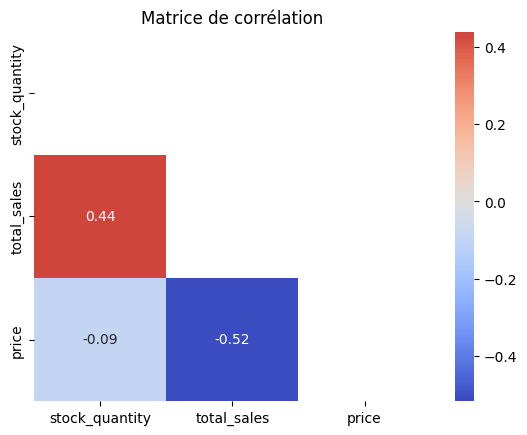

In [681]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

cols_corr = ['stock_quantity', 'total_sales', 'price']
corr_matrix = df_merge[cols_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

ax = sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f')
ax.set_title('Matrice de corrélation')


In [677]:
#Que peut-on conclure des corrélations ?

La corrélation négative modérée entre price & total_sales montre que les articles les plus chers se vendent moins
La corrélation positive modérée entre total_sales & stock_quantity montre que les articles les plus vendus ont plus de stock

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [678]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_merge.to_excel('df_merge_bottleneck.xlsx', index=False)